## Modelagem do Perceptron

In [1]:
import numpy as np

In [2]:
def sigma(v):
  return 1 if v >= 0 else 0

def predict(x,w,b):
  return sigma(w @ x + b)

def train(X,y,w,b,eta, epochs=1000):
  for i in range(epochs):
    for x, y_true in zip(X,y):
      y_hat = predict(x,w,b)
      w = w + eta * (y_true - y_hat) * x
      b = b + eta * (y_true - y_hat)
  return w,b


In [5]:
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([0,1,1,1])

# Inicialização de pesos e bias
w = np.array([0.5,-1.5])
b = 2

y_hat = np.zeros(len(X))
# online - uma linha por vez
for i in range(len(X)):
    y_hat[i] = predict(X[i,:],w,b)

In [6]:
import pandas as pd

pd.DataFrame({'X1': X[:,0], 'X2': X[:,1], 'y': y, 'y_hat': y_hat})

,X1,X2,y,y_hat
0,0,0,0,1.0
1,0,1,1,1.0
2,1,0,1,1.0
3,1,1,1,1.0


In [7]:
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([0,1,1,1])

# Inicialização de pesos e bias
w = np.array([0.5,-1.5])
b = 2

# loop de treinamento
w,b = train(X,y,w,b,0.1)
print(w,b)

[0.5 0.1] -6.38378239159465e-16


In [9]:
for x, y_true in zip(X,y):
      y_hat = predict(x,w,b)
      print(f"x: {x} y_true: {y_true} y_hat: {y_hat}")

x: [0 0] y_true: 0 y_hat: 0
x: [0 1] y_true: 1 y_hat: 1
x: [1 0] y_true: 1 y_hat: 1
x: [1 1] y_true: 1 y_hat: 1


In [10]:
y_hat = np.zeros(len(X))
# online - uma linha por vez
for i in range(len(X)):
    y_hat[i] = predict(X[i,:],w,b)

Após a correção

In [11]:
pd.DataFrame({'X1': X[:,0], 'X2': X[:,1], 'y': y, 'y_hat': y_hat})

,X1,X2,y,y_hat
0,0,0,0,0.0
1,0,1,1,1.0
2,1,0,1,1.0
3,1,1,1,1.0


Versão aprimorada

In [12]:
class Perceptron:
  def __init__(self, input_size, eta=0.1, epochs=1000):
    self.w = np.zeros(input_size)
    self.b = 0
    self.eta = eta
    self.epochs = epochs

  def getParam(self):
    return {'w': self.w,
            'b': self.b}

  def sigma(self, v):
    return 1 if v >= 0 else 0

  def predict(self, x):
    w = self.w
    b = self.b
    return self.sigma(w @ x + b)

  def train(self, X,y):
    w,b,eta = self.w, self.b, self.eta
    epochs = self.epochs

    for i in range(epochs):
      for x, y_true in zip(X,y):
        y_hat = self.predict(x)
        w = w + eta * (y_true - y_hat) * x
        b = b + eta * (y_true - y_hat)

    self.w = w
    self.b = b

In [13]:
p = Perceptron(input_size=2)

X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([0,1,1,1])

p.train(X,y)

## Função sigmóide (contínua)

In [15]:
def sigma(z):
  return 1./(1+np.exp(-z))

def diff_sigma(z):
  s = sigma(z)
  return s*(1-s)

In [16]:
sigma(2.6)

np.float64(0.9308615796566533)

In [17]:
diff_sigma(2.6)

np.float64(0.06435829917577342)

In [19]:
xx = np.linspace(-5,5,100)
zz = [sigma(x) for x in xx]
zz_diff = [diff_sigma(x) for x in xx]

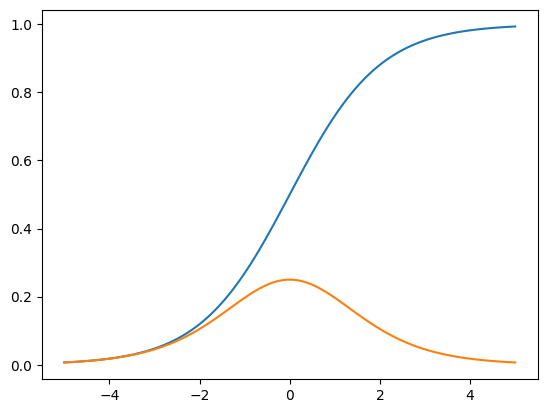

In [20]:
import matplotlib.pyplot as plt

plt.plot(xx,zz)
plt.plot(xx,zz_diff)
plt.show()

## Exemplo Múltiplas camadas

In [21]:
import numpy as np
from numpy.random import rand

np.random.seed(42)

In [22]:
def sigma(z):
  return 1./(1+np.exp(-z))

def diff_sigma(z):
  s = sigma(z)
  return s*(1-s)

In [23]:
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([0,1,1,1])

In [24]:
input_size = 2
hidden_size = 3
output_size = 1

# Transformação de [0,1] para [-1,1]
W1 = 2*rand(input_size, hidden_size) - 1
W2 = 2*rand(hidden_size, output_size) - 1

Como encontrar os coeficientes? Sistema linear

In [36]:
# Como generalizar para qualquer caso?
def encontra_coeficientes(intervalo_original, intervalo_mapeado): 
    A = np.array([[intervalo_original[0],1],
              [intervalo_original[1],1]])
    b = np.array([[intervalo_mapeado[0]],
                  [intervalo_mapeado[1]]])
    return np.linalg.solve(A, b)

In [44]:
encontra_coeficientes([0,1],[-1,1]) # entre -1 e 1

array([[ 2.],
       [-1.]])

In [45]:
2*X-1

array([[-1, -1],
       [-1,  1],
       [ 1, -1],
       [ 1,  1]])

In [43]:
encontra_coeficientes([0,1],[-10,10]) # entre -10 e 10

array([[ 20.],
       [-10.]])

In [46]:
W1

array([[-0.25091976,  0.90142861,  0.46398788],
       [ 0.19731697, -0.68796272, -0.68801096]])

In [47]:
W2

array([[-0.88383278],
       [ 0.73235229],
       [ 0.20223002]])

In [52]:
sigma(X[0] @ W1)

array([0.5, 0.5, 0.5])

In [53]:
z1 = X[0] @  W1
a1 = sigma(z1)

z2 = a1 @ W2
a2 = sigma(z2)

print(a1,a2)

[0.5 0.5 0.5] [0.50634335]


In [54]:
z1 = X[1] @  W1
a1 = sigma(z1)

z2 = a1 @ W2
a2 = sigma(z2)

print(a1,a2)

[0.54916981 0.33448643 0.33447569] [0.45691428]


In [64]:
y_hat = np.zeros(len(X))

for i in range(len(X)):
    z1 = X[i] @  W1
    a1 = sigma(z1)

    z2 = a1 @ W2
    a2 = sigma(z2)

    y_hat[i] = np.round(a2)

C:\Users\307145\AppData\Local\Temp\ipykernel_14140\3940992306.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_hat[i] = np.round(a2)


In [65]:
pd.DataFrame({'X1': X[:,0], 'X2': X[:,1], 'y': y, 'y_hat': y_hat.flatten()})

,X1,X2,y,y_hat
0,0,0,0,1.0
1,0,1,1,0.0
2,1,0,1,1.0
3,1,1,1,1.0
